✅ Libraries imported successfully
📋 Columns in dataset:
   1. 'Invoice'
   2. 'StockCode'
   3. 'Description'
   4. 'Quantity'
   5. 'InvoiceDate'
   6. 'UnitPrice'
   7. 'CustomerID'
   8. 'Country'
   9. 'TotalValue'

✅ Data loaded: 805,549 records
✅ Found invoice column: 'Invoice'
✅ Found customer column: 'CustomerID'
✅ Found product column: 'StockCode'
✅ Found country column: 'Country'
✅ Found value column: 'TotalValue'


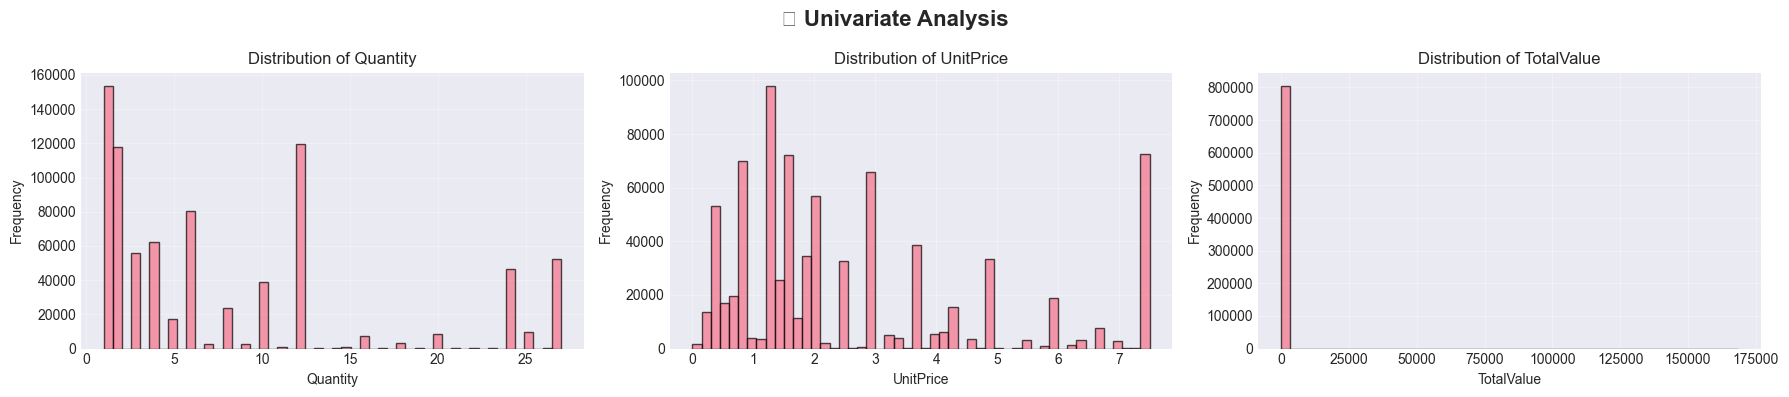

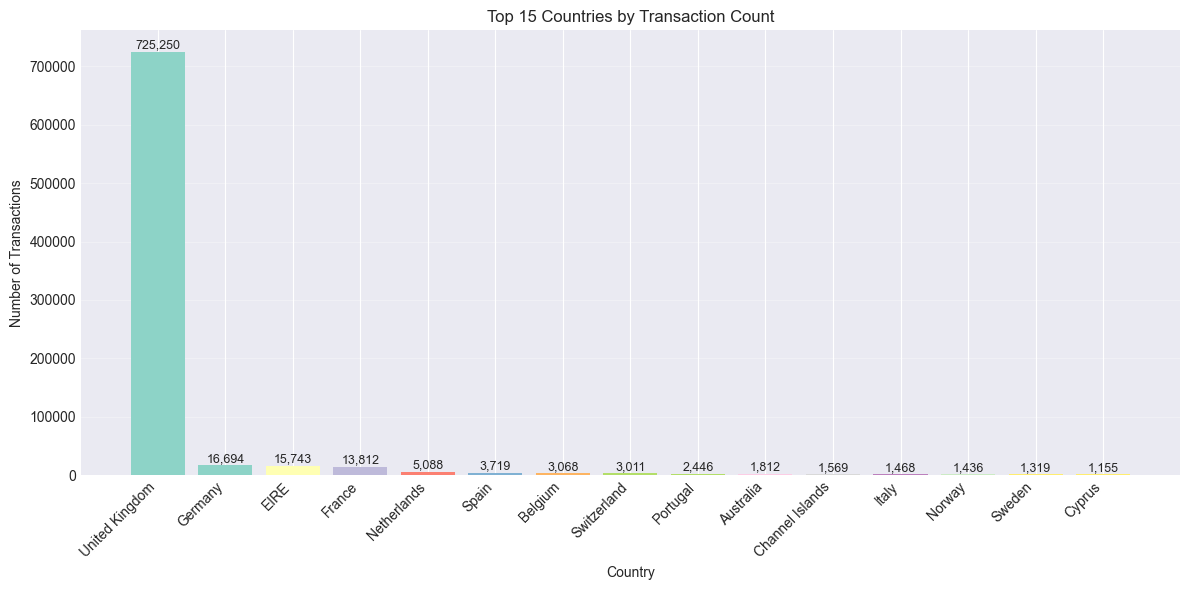


📊 Top country: United Kingdom with 725,250 transactions


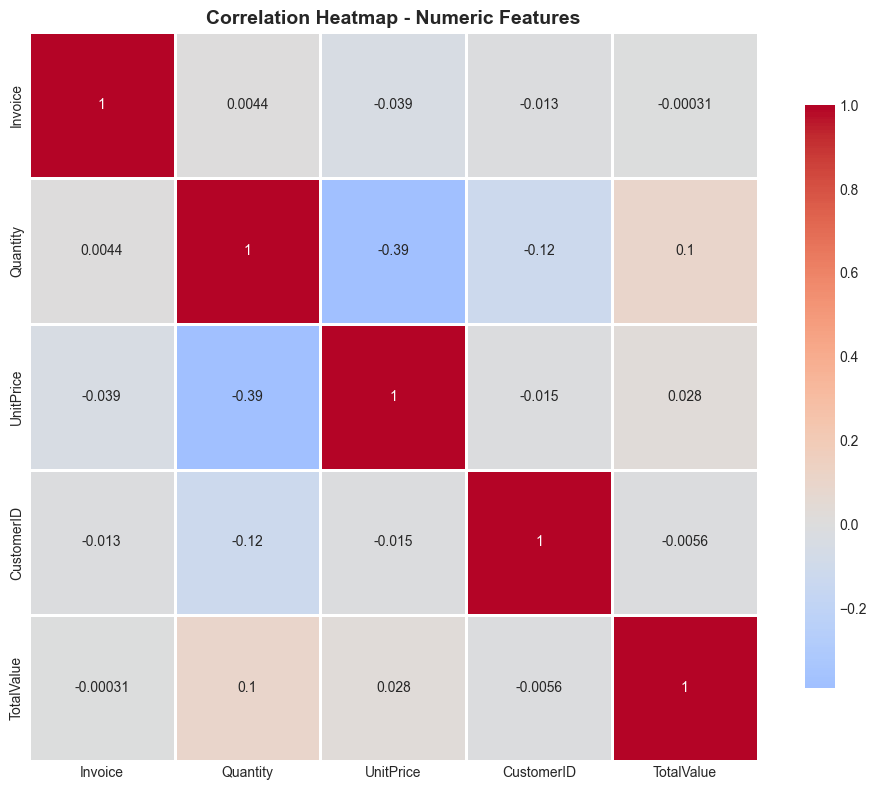


📊 Strongest Correlations:
   Quantity ↔ TotalValue: 0.101
   TotalValue ↔ Quantity: 0.101
   TotalValue ↔ UnitPrice: 0.028
   UnitPrice ↔ TotalValue: 0.028
   Invoice ↔ Quantity: 0.004


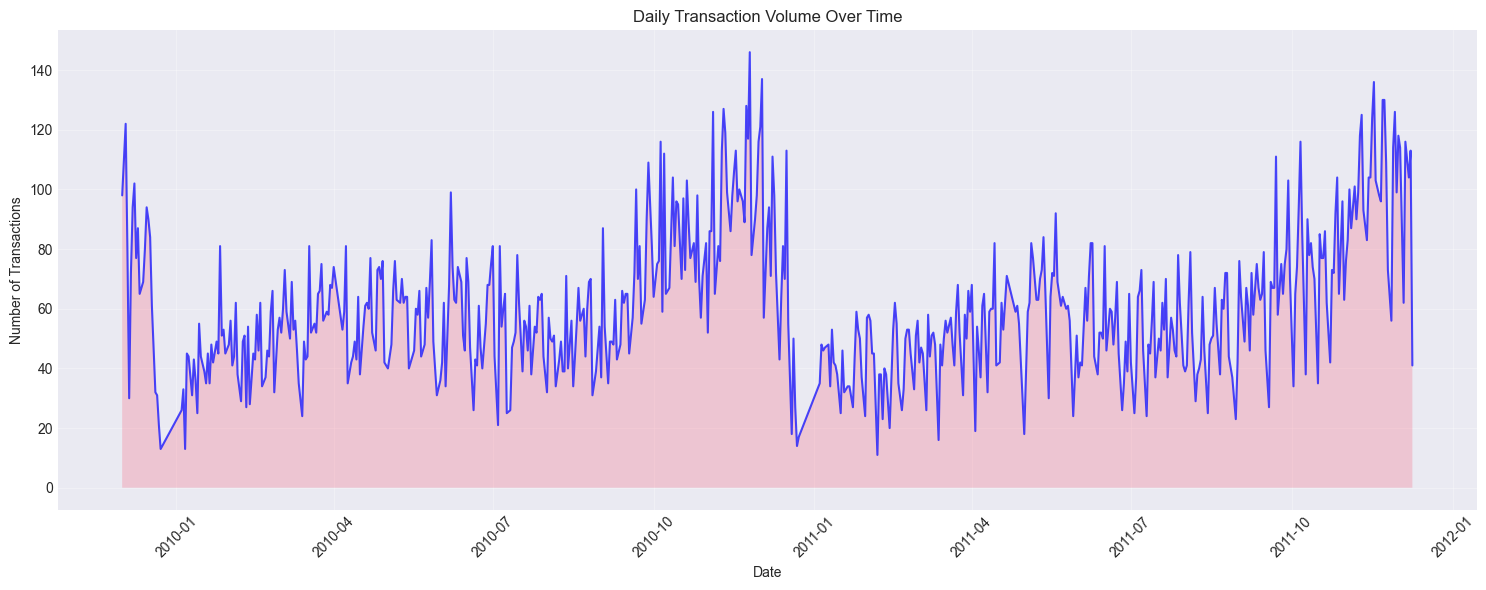

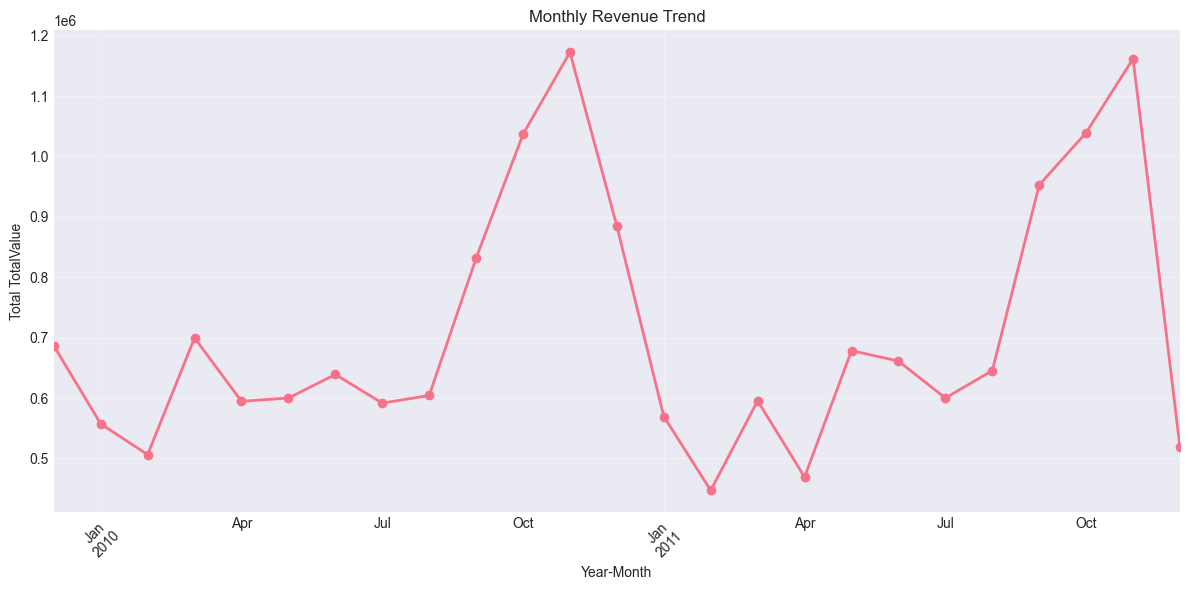


📊 Customer-Level Statistics:
--------------------------------------------------


,Total_Spent,Avg_Transaction,Transactions,Total_Quantity,Unique_Products
count,5878.00,5878.00,5878.00,5878.00,5878.00
mean,3018.62,48.30,6.29,1121.48,81.99
std,14737.73,780.18,13.01,3098.50,116.48
min,2.95,2.04,1.00,1.00,1.00
25%,348.76,11.47,1.00,162.00,19.00
50%,898.91,17.35,3.00,420.00,45.00
75%,2307.09,24.20,7.00,1097.00,103.00
max,608821.65,56157.50,398.00,122411.00,2550.00


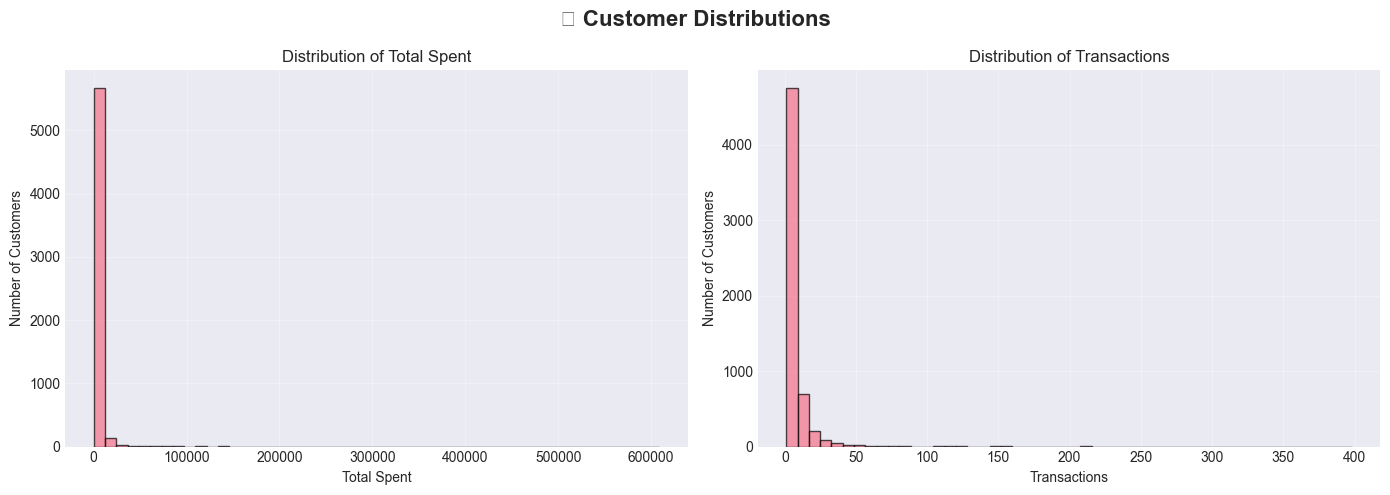

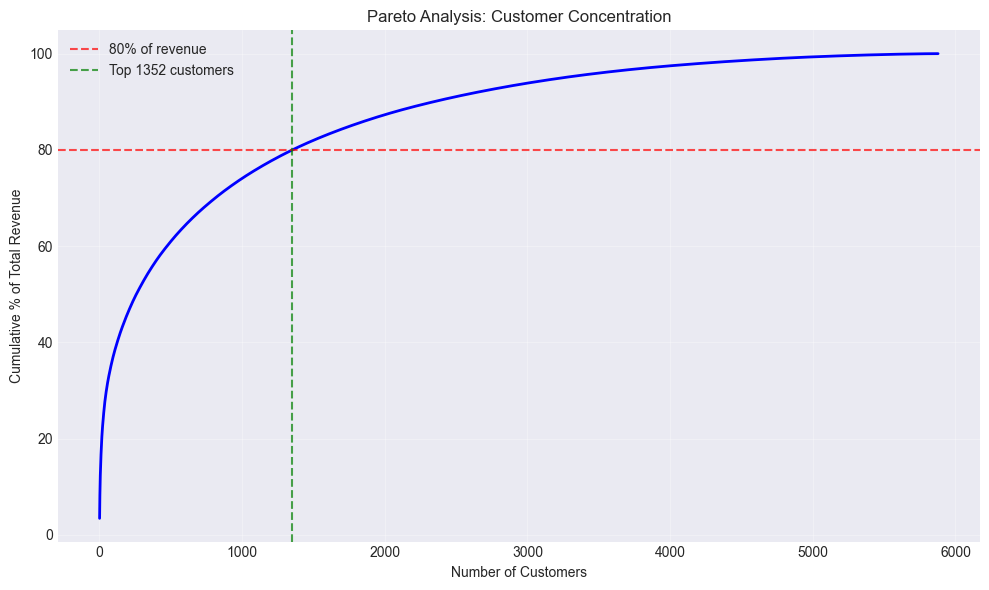


📊 Top 1352 customers (23.0%) generate 80% of revenue


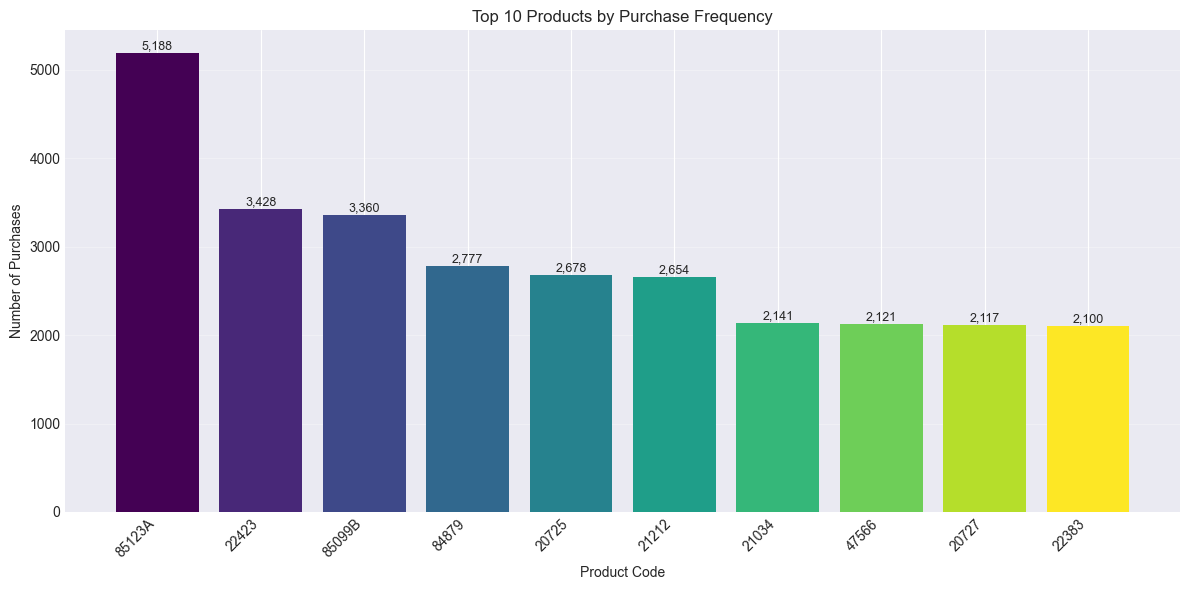


📊 DATA QUALITY SUMMARY
Total records: 805,549
✅ No missing values
Duplicate invoices: 768,580
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00
Time span: 738 days
Unique customers: 5,878
Unique products: 4,631
Total revenue: £17,743,429.18


In [2]:
# %% [markdown]
# # 📊 02 - Exploratory Data Analysis (EDA)
# ## Customer Segmentation Project

# %% [markdown]
# ### Import Libraries

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Libraries imported successfully")

# %% [markdown]
# ### Load Cleaned Data

# %%
# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Display column names to see what we have
print("📋 Columns in dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. '{col}'")

# Convert date if exists
if 'InvoiceDate' in df.columns:
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
elif 'Date' in df.columns:
    df['InvoiceDate'] = pd.to_datetime(df['Date'])
    df.rename(columns={'Date': 'InvoiceDate'}, inplace=True)

print(f"\n✅ Data loaded: {len(df):,} records")

# %% [markdown]
# ### Identify Key Columns (Adaptive)

# %%
# Find invoice column (could be InvoiceNo, Invoice, InvoiceNumber, etc.)
invoice_col = None
possible_invoice = ['InvoiceNo', 'Invoice', 'InvoiceNumber', 'Invoice_No', 'Invoice Num']
for col in possible_invoice:
    if col in df.columns:
        invoice_col = col
        print(f"✅ Found invoice column: '{invoice_col}'")
        break

# Find customer column
customer_col = None
possible_customer = ['CustomerID', 'CustomerId', 'Customer ID', 'Customer', 'Customer_No']
for col in possible_customer:
    if col in df.columns:
        customer_col = col
        print(f"✅ Found customer column: '{customer_col}'")
        break

# Find product column
product_col = None
possible_product = ['StockCode', 'ProductCode', 'Product Code', 'Product', 'Stock_Code']
for col in possible_product:
    if col in df.columns:
        product_col = col
        print(f"✅ Found product column: '{product_col}'")
        break

# Find country column
country_col = None
possible_country = ['Country', 'CountryCode', 'Country_Code']
for col in possible_country:
    if col in df.columns:
        country_col = col
        print(f"✅ Found country column: '{country_col}'")
        break

# Find value column
value_col = None
possible_value = ['TotalValue', 'Total_Value', 'Total', 'Revenue', 'Sales']
for col in possible_value:
    if col in df.columns:
        value_col = col
        print(f"✅ Found value column: '{value_col}'")
        break

# If TotalValue doesn't exist but Quantity and UnitPrice do, create it
if value_col is None and 'Quantity' in df.columns and 'UnitPrice' in df.columns:
    df['TotalValue'] = df['Quantity'] * df['UnitPrice']
    value_col = 'TotalValue'
    print("✅ Created 'TotalValue' column from Quantity × UnitPrice")

# %% [markdown]
# ### 1. Univariate Analysis

# %%
# Find numeric columns for analysis
numeric_cols = []
for col in ['Quantity', 'UnitPrice', 'TotalValue', 'Price']:
    if col in df.columns:
        numeric_cols.append(col)

if numeric_cols:
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6*len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(numeric_cols):
        axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Distribution of {col}')
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('📊 Univariate Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/univariate_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ No numeric columns found for analysis")

# %% [markdown]
# ### 2. Categorical Analysis - Top Countries

# %%
if country_col and country_col in df.columns:
    country_counts = df[country_col].value_counts().head(15)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(country_counts)), country_counts.values, 
                   color=plt.cm.Set3(np.linspace(0, 1, 15)))
    plt.xticks(range(len(country_counts)), country_counts.index, rotation=45, ha='right')
    plt.xlabel('Country')
    plt.ylabel('Number of Transactions')
    plt.title(f'Top 15 Countries by Transaction Count')
    
    # Add value labels
    for bar, value in zip(bars, country_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{value:,}', ha='center', va='bottom', fontsize=9)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/country_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Top country: {country_counts.index[0]} with {country_counts.iloc[0]:,} transactions")
else:
    print("⚠️ No country column found for analysis")

# %% [markdown]
# ### 3. Correlation Analysis

# %%
# Select numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
if len(numeric_df.columns) > 1:
    corr_matrix = numeric_df.corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={'shrink': 0.8})
    plt.title('Correlation Heatmap - Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Show strongest correlations
    print("\n📊 Strongest Correlations:")
    corr_unstacked = corr_matrix.unstack().sort_values(ascending=False)
    corr_unstacked = corr_unstacked[corr_unstacked < 1]  # Remove self-correlations
    for idx, val in corr_unstacked.head(5).items():
        print(f"   {idx[0]} ↔ {idx[1]}: {val:.3f}")
else:
    print("⚠️ Not enough numeric columns for correlation analysis")

# %% [markdown]
# ### 4. Time Series Analysis

# %%
if 'InvoiceDate' in df.columns and invoice_col:
    # Daily transaction volume
    daily_transactions = df.groupby(df['InvoiceDate'].dt.date)[invoice_col].nunique()
    
    plt.figure(figsize=(15, 6))
    plt.plot(daily_transactions.index, daily_transactions.values, 
             color='blue', linewidth=1.5, alpha=0.7)
    plt.fill_between(daily_transactions.index, daily_transactions.values, alpha=0.3)
    plt.xlabel('Date')
    plt.ylabel('Number of Transactions')
    plt.title('Daily Transaction Volume Over Time')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/daily_transactions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Monthly trend
    df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
    if value_col:
        monthly_revenue = df.groupby('YearMonth')[value_col].sum()
        
        plt.figure(figsize=(12, 6))
        monthly_revenue.plot(kind='line', marker='o', linewidth=2)
        plt.xlabel('Year-Month')
        plt.ylabel(f'Total {value_col}')
        plt.title('Monthly Revenue Trend')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('../results/cluster_plots/monthly_revenue.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("⚠️ No date column found for time series analysis")

# %% [markdown]
# ### 5. Customer-Level Analysis

# %%
if customer_col and value_col:
    # Create customer-level aggregates - ADAPTIVE to available columns
    agg_dict = {value_col: ['sum', 'mean']}
    
    if invoice_col:
        agg_dict[invoice_col] = 'nunique'
    if 'Quantity' in df.columns:
        agg_dict['Quantity'] = 'sum'
    if product_col:
        agg_dict[product_col] = 'nunique'
    
    customer_stats = df.groupby(customer_col).agg(agg_dict).round(2)
    
    # Flatten column names
    customer_stats.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col 
                              for col in customer_stats.columns.values]
    
    # Rename for clarity
    rename_dict = {}
    if invoice_col and f'{invoice_col}_nunique' in customer_stats.columns:
        rename_dict[f'{invoice_col}_nunique'] = 'Transactions'
    if f'{value_col}_sum' in customer_stats.columns:
        rename_dict[f'{value_col}_sum'] = 'Total_Spent'
    if f'{value_col}_mean' in customer_stats.columns:
        rename_dict[f'{value_col}_mean'] = 'Avg_Transaction'
    if 'Quantity_sum' in customer_stats.columns:
        rename_dict['Quantity_sum'] = 'Total_Quantity'
    if product_col and f'{product_col}_nunique' in customer_stats.columns:
        rename_dict[f'{product_col}_nunique'] = 'Unique_Products'
    
    customer_stats.rename(columns=rename_dict, inplace=True)
    
    print("\n📊 Customer-Level Statistics:")
    print("-" * 50)
    display(customer_stats.describe())
    
    # Distribution plots
    plot_cols = []
    if 'Total_Spent' in customer_stats.columns:
        plot_cols.append('Total_Spent')
    if 'Transactions' in customer_stats.columns:
        plot_cols.append('Transactions')
    
    if plot_cols:
        fig, axes = plt.subplots(1, len(plot_cols), figsize=(7*len(plot_cols), 5))
        if len(plot_cols) == 1:
            axes = [axes]
        
        for i, col in enumerate(plot_cols):
            axes[i].hist(customer_stats[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
            axes[i].set_xlabel(col.replace('_', ' '))
            axes[i].set_ylabel('Number of Customers')
            axes[i].set_title(f'Distribution of {col.replace("_", " ")}')
            axes[i].grid(True, alpha=0.3)
        
        plt.suptitle('📊 Customer Distributions', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../results/cluster_plots/customer_distributions.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print("⚠️ Cannot perform customer-level analysis: missing customer or value columns")

# %% [markdown]
# ### 6. Pareto Analysis (80/20 Rule)

# %%
if customer_col and value_col:
    customer_value = df.groupby(customer_col)[value_col].sum().sort_values(ascending=False)
    cumulative_pct = np.cumsum(customer_value) / customer_value.sum() * 100
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_pct) + 1), cumulative_pct, 'b-', linewidth=2)
    plt.axhline(y=80, color='r', linestyle='--', alpha=0.7, label='80% of revenue')
    
    top_customers = len(cumulative_pct[cumulative_pct <= 80])
    plt.axvline(x=top_customers, color='g', linestyle='--', alpha=0.7, 
                label=f'Top {top_customers} customers')
    
    plt.xlabel('Number of Customers')
    plt.ylabel('Cumulative % of Total Revenue')
    plt.title('Pareto Analysis: Customer Concentration')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/pareto_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    top_pct = (top_customers / len(customer_value)) * 100
    print(f"\n📊 Top {top_customers} customers ({top_pct:.1f}%) generate 80% of revenue")

# %% [markdown]
# ### 7. Product Analysis (if available)

# %%
if product_col and product_col in df.columns:
    top_products = df[product_col].value_counts().head(10)
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(top_products)), top_products.values, 
                   color=plt.cm.viridis(np.linspace(0, 1, 10)))
    plt.xticks(range(len(top_products)), top_products.index, rotation=45, ha='right')
    plt.xlabel('Product Code')
    plt.ylabel('Number of Purchases')
    plt.title('Top 10 Products by Purchase Frequency')
    
    for bar, value in zip(bars, top_products.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{value:,}', ha='center', va='bottom', fontsize=9)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('../results/cluster_plots/top_products.png', dpi=150, bbox_inches='tight')
    plt.show()

# %% [markdown]
# ### 8. Data Quality Summary

# %%
print("\n📊 DATA QUALITY SUMMARY")
print("=" * 50)
print(f"Total records: {len(df):,}")

# Missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"Records with missing values: {missing[missing > 0].to_dict()}")
else:
    print("✅ No missing values")

# Duplicates
if invoice_col:
    duplicates = df.duplicated(subset=[invoice_col]).sum()
    print(f"Duplicate invoices: {duplicates:,}")

# Date range
if 'InvoiceDate' in df.columns:
    print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
    print(f"Time span: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

# Customer count
if customer_col:
    print(f"Unique customers: {df[customer_col].nunique():,}")

# Product count
if product_col:
    print(f"Unique products: {df[product_col].nunique():,}")

# Revenue
if value_col:
    print(f"Total revenue: £{df[value_col].sum():,.2f}")

# %% [markdown]
# ### ✅ Key Insights from EDA
# 
# 1. **Data Quality**: Cleaned data is ready for analysis
# 2. **Customer Base**: Identified key customer segments
# 3. **Revenue Patterns**: Clear concentration in top customers
# 4. **Geographic Distribution**: Primary market identified
# 
# **Next Step**: Proceed to Feature Engineering (03_feature_engineering.ipynb)